# 다중공선성 분석 (VIF)
- 대상 파일: `Membership_v2_with_derived_features.csv`
- VIF > 10: 다중공선성 심각, inf: 완전 선형 결합

In [1]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

df = pd.read_csv('Membership_v2_with_derived_features.csv')

# 수치형 컬럼만 선택
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
X = df[num_cols].dropna()

# 분산 0인 컬럼 제거 (상수 컬럼)
X = X.loc[:, X.var() > 0]

print(f'분석 대상 컬럼 수: {X.shape[1]}')
X.head(3)

분석 대상 컬럼 수: 85


,price,billing_method,max_screen,is_promotion,is_churn_prevented,is_user_verified,age,reg_hour,is_repurchase,is_standard,...,family_animation_ratio,drama_ratio,thriller_crime_ratio,sf_fantasy_ratio,comedy_ratio,romance_ratio,horror_ratio,documentary_ratio,historical_war_ratio,other_ratio
0,100.0,134,4.0,1,0,1,20.0,20,1,0,...,0.003861,0.389961,0.361004,0.0,0.000000,0.013514,0.0,0.0,0.0,0.001931
1,100.0,190,1.0,1,1,1,25.0,14,0,0,...,0.000000,0.250000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000
2,100.0,180,2.0,1,0,1,20.0,2,0,1,...,0.000000,0.000000,0.992248,0.0,0.007752,0.000000,0.0,0.0,0.0,0.000000


In [2]:
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

vif_data

c:\Users\82109\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
0,watch_time(min)_w2,inf
1,is_premium,inf
2,watch_time(min)_w1,inf
3,reg_hour_night,inf
4,reg_hour_evening,inf
...,...,...
80,is_repurchase,1.422326
81,weekend_watch_ratio,1.116187
82,is_churn_prevented,1.089321
83,billing_method,1.077304


In [3]:
# 구간별 요약
inf_cols  = vif_data[vif_data['VIF'] == np.inf]
high_cols = vif_data[(vif_data['VIF'] > 10) & (vif_data['VIF'] != np.inf)]
ok_cols   = vif_data[vif_data['VIF'] <= 10]

print(f'=== inf (완전 다중공선성): {len(inf_cols)}개 ===')
print(inf_cols['feature'].tolist())

print(f'\n=== VIF > 10 (심각): {len(high_cols)}개 ===')
print(high_cols[['feature', 'VIF']].to_string(index=False))

print(f'\n=== VIF <= 10 (양호): {len(ok_cols)}개 ===')
print(ok_cols[['feature', 'VIF']].to_string(index=False))

=== inf (완전 다중공선성): 18개 ===
['watch_time(min)_w2', 'is_premium', 'watch_time(min)_w1', 'reg_hour_night', 'reg_hour_evening', 'reg_hour_afternoon', 'reg_hour_morning', 'total_watch_time(min)', 'diff_between_w3_w2', 'total_watch_count', 'is_standard', 'diff_between_w3_w1', 'diff_between_w2_w1', 'watch_session_w3', 'watch_session_w2', 'watch_session_w1', 'watch_time(min)_w3', 'max_screen']

=== VIF > 10 (심각): 33개 ===
                  feature          VIF
               watch_days 1.488793e+12
             active_ratio 1.488793e+12
              drama_ratio 3.304269e+05
   family_animation_ratio 2.981185e+05
         sf_fantasy_ratio 2.920044e+05
     avg_ott_release_year 2.541417e+05
     thriller_crime_ratio 2.455312e+05
   action_adventure_ratio 2.248591e+05
            romance_ratio 2.027768e+05
             comedy_ratio 1.896012e+05
     historical_war_ratio 1.435664e+05
              other_ratio 6.709748e+04
             horror_ratio 5.847909e+04
        documentary_ratio 4.331393e+

---
# 상관관계 분석

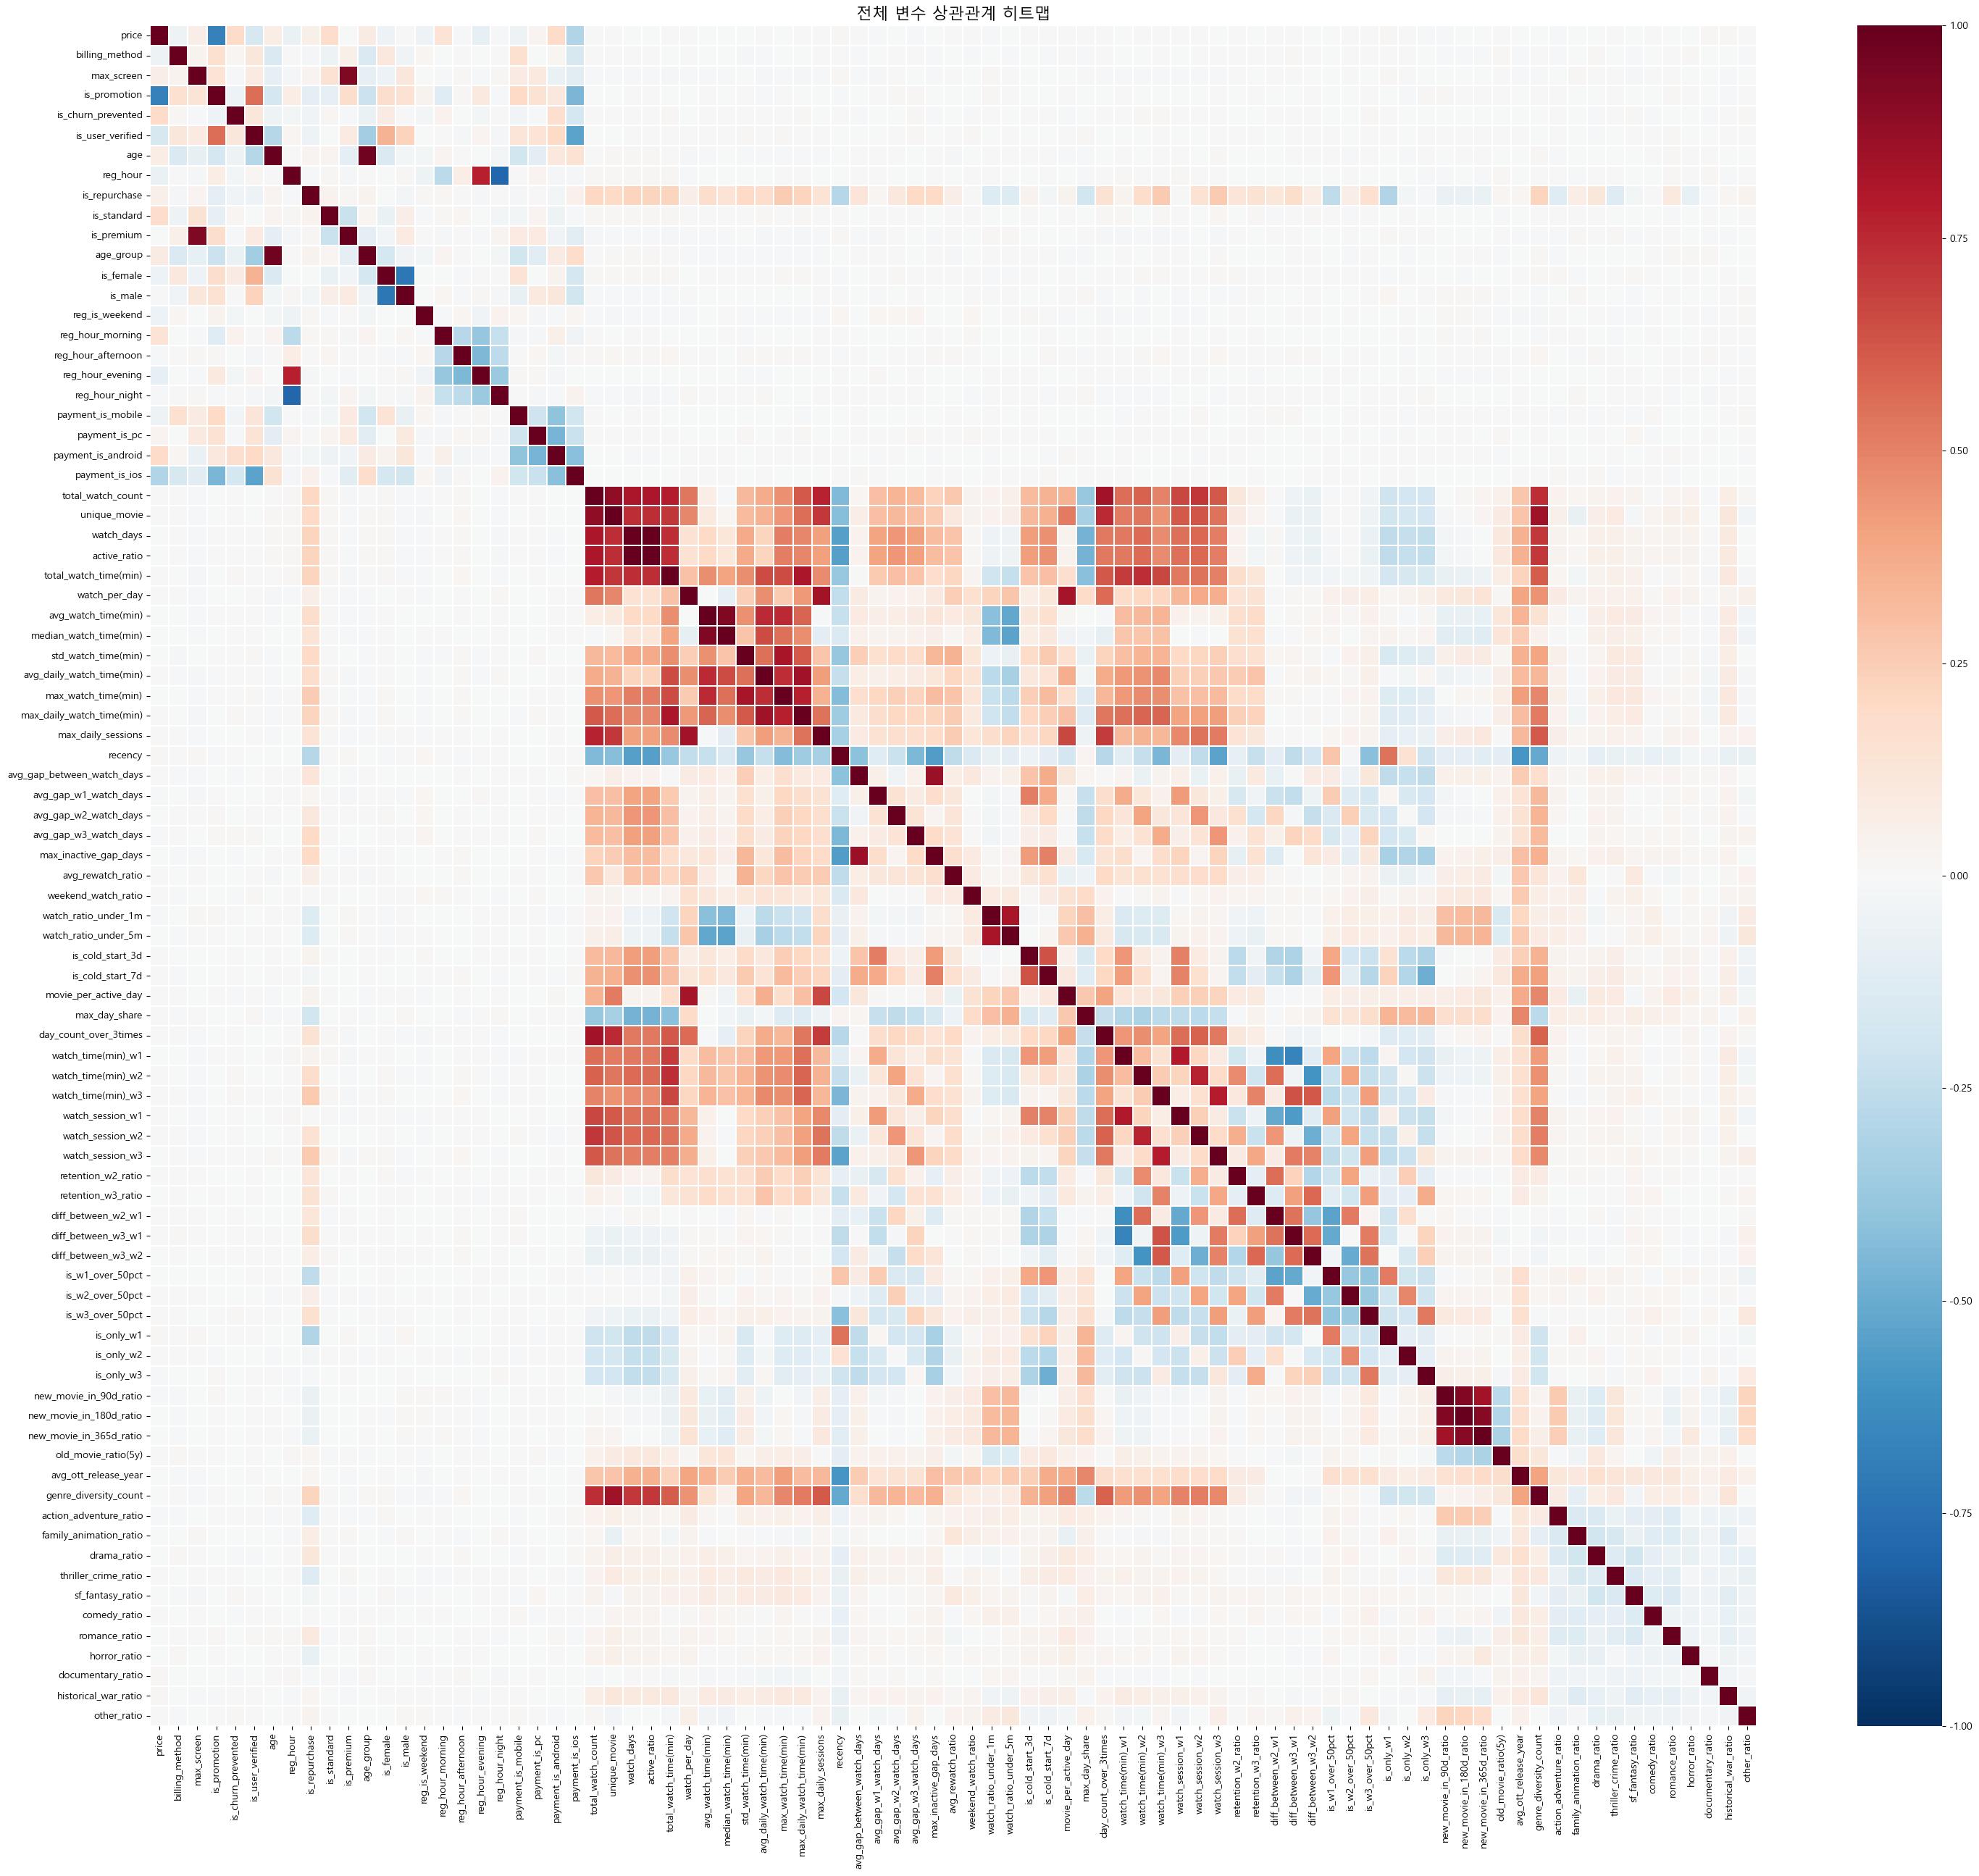

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rc

rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

corr = X.corr()

# 전체 히트맵
fig, ax = plt.subplots(figsize=(30, 26))
sns.heatmap(
    corr,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    annot=False,
    linewidths=0.3,
    ax=ax
)
ax.set_title('전체 변수 상관관계 히트맵', fontsize=16)
plt.tight_layout()
plt.show()

In [5]:
# |상관계수| > 0.8인 변수 쌍 추출
threshold = 0.8

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'var1', 'level_1': 'var2', 0: 'corr'})
)
high_corr_pairs = high_corr_pairs[high_corr_pairs['corr'].abs() >= threshold]
high_corr_pairs = high_corr_pairs.reindex(
    high_corr_pairs['corr'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

print(f'|상관계수| >= {threshold} 변수 쌍: {len(high_corr_pairs)}개')
high_corr_pairs

|상관계수| >= 0.8 변수 쌍: 19개


,var1,var2,corr
0,watch_days,active_ratio,1.000000
1,age,age_group,0.974634
2,max_screen,is_premium,0.931850
3,avg_watch_time(min),median_watch_time(min),0.929465
4,new_movie_in_90d_ratio,new_movie_in_180d_ratio,0.926120
5,new_movie_in_180d_ratio,new_movie_in_365d_ratio,0.913362
6,total_watch_count,unique_movie,0.888531
7,avg_gap_between_watch_days,max_inactive_gap_days,0.865440
8,unique_movie,genre_diversity_count,0.847535
9,avg_daily_watch_time(min),max_daily_watch_time(min),0.845034


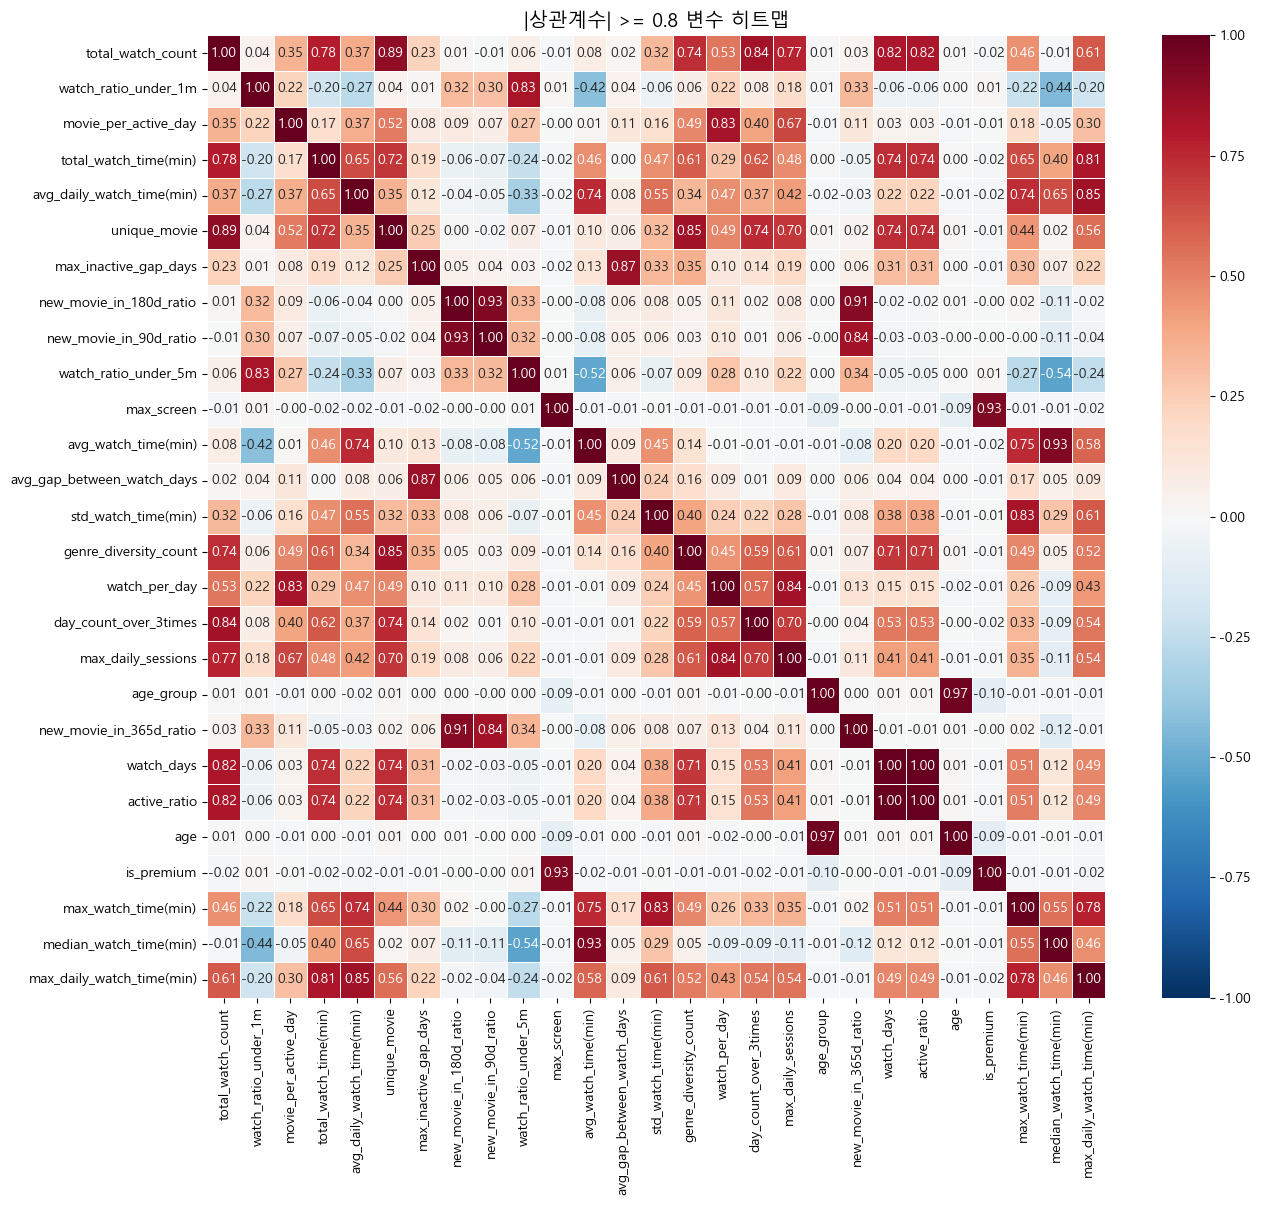

In [6]:
# 높은 상관관계 변수만 모아서 히트맵 시각화
high_vars = list(set(high_corr_pairs['var1'].tolist() + high_corr_pairs['var2'].tolist()))
corr_sub = corr.loc[high_vars, high_vars]

fig, ax = plt.subplots(figsize=(max(10, len(high_vars) * 0.5), max(8, len(high_vars) * 0.45)))
sns.heatmap(
    corr_sub,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    ax=ax
)
ax.set_title(f'|상관계수| >= {threshold} 변수 히트맵', fontsize=14)
plt.tight_layout()
plt.show()

## 조치 필요 목록

| 문제 | 해당 변수 | 조치 |
|------|-----------|------|
| `watch_days / 21 = active_ratio` | `watch_days`, `active_ratio` | 둘 중 하나 제거 |
| `w1+w2+w3 = total_watch_time` | `watch_time(min)_w1/w2/w3`, `total_watch_time(min)` | total 또는 주차별 중 선택 |
| `w1+w2+w3 = total_watch_count` | `watch_session_w1/w2/w3`, `total_watch_count` | 동일 |
| diff 선형 결합 | `diff_between_w2_w1`, `diff_between_w3_w1`, `diff_between_w3_w2` | 최대 2개만 유지 |
| 더미 완전 분리 | `reg_hour_morning/afternoon/evening/night` | 기준 범주 1개 제거 |
| 원본+파생 중복 | `max_screen`, `is_standard`, `is_premium` | `max_screen` 제거 또는 더미 중 하나 제거 |
| 장르 비율 합=1 | `action_adventure_ratio` ... `other_ratio` | `other_ratio` 제거 |